# 05 — R2N2: Where Learned Inner Coefficients Help, and Where They Provably Cannot

**Learned Iterative Solvers for AC Power Flow** · Notebook 5 of a series

---

Notebook 02 ended with a diagnosis: our frozen solver used a subspace generated by raw
powers $\mathbf{A}^j\mathbf{b}$, and that basis dies past $m\approx5$
($\kappa_2(\mathbf{W})>10^{14}$). Notebook 04 found the fix in miniature — give the
**inner** recurrence its own learnable coefficients, and a two-stage Runge–Kutta method
reaches third order, which no choice of outer weights alone could deliver.

R2N2 [5] is that idea generalised from integrators to solvers. This notebook applies it to
power flow, and the result is not what the roadmap predicted. The short version:

> Learned inner coefficients help exactly when the inner function evaluations carry
> information that a Krylov subspace does not. For the **linear** subproblem they provably
> cannot — and we measure the predicted loss. For the **nonlinear** residual they can, and
> R2N2 reaches parity with the far simpler frozen polynomial of notebooks 02–03.

This turns out to agree with [5], which says as much in its own §4. Getting there required
one wrong prediction of mine and one divergence to $10^{91}$, both recorded below.

### References

| | |
|---|---|
| **[1]** | Monga, Li & Eldar, *Algorithm Unrolling*, IEEE SPM 38(2), 2021 |
| **[2]** | Gregor & LeCun, *Learning Fast Approximations of Sparse Coding*, ICML 2010 |
| **[3]** | Saad, *Iterative Methods for Sparse Linear Systems*, 2nd ed., SIAM 2003 |
| **[4]** | Guo, Dietrich, Bertalan, Doncevic, Dahmen, Kevrekidis & Li, *Personalized Algorithm Generation: A Case Study in Learning ODE Integrators*, SIAM J. Sci. Comput. 44(4), 2022 |
| **[5]** | Doncevic, Mitsos, Guo, Li, Dietrich, Dahmen & Kevrekidis, *A Recursively Recurrent Neural Network (R2N2) Architecture for Learning Iterative Algorithms*, SIAM J. Sci. Comput. 46(2), 2024 |

In [1]:
import sys, warnings, time
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, torch
import scipy.sparse as sp, scipy.sparse.linalg as spla

from lis import load_case, newton_pf, build_jacobian, mismatch
from lis.instances import n1_variants
from lis.r2n2 import R2N2, basis_condition
from lis.krylov import gmres, apply_poly
from lis.torch_pf import TorchPF
from lis.jacobian_free import PolarResidual, fd_matvec
from lis.plotting import use_style, save, stacked, suptitle, annotate_tolerance, PALETTE, plt

use_style(); torch.set_default_dtype(torch.float64)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV)

BASE = load_case("case118")
N1 = [v for v, r in ((v, newton_pf(v, tol=1e-10)) for v in n1_variants(BASE)) if r.converged]
IDX = np.random.default_rng(0).permutation(len(N1)); TR, TE = IDX[:80], IDX[80:]
rb = newton_pf(BASE, store_history=True)
Jb = build_jacobian(rb.v, BASE.ybus, BASE.pv, BASE.pq)
ILU = spla.spilu(sp.csc_matrix(Jb), drop_tol=1e-4, fill_factor=10)
NN = Jb.shape[0]
Minv_np = np.column_stack([ILU.solve(np.eye(NN)[:, i]) for i in range(NN)])
Minv = torch.tensor(Minv_np, device=DEV)
print(f"{len(N1)} convergent N-1 contingencies | {len(TR)} train / {len(TE)} test | n = {NN}")

device:

cuda

177 convergent N-1 contingencies | 80 train / 97 test | n = 181

---
## 1. The architecture

One forward pass of R2N2 is one iteration of a numerical algorithm ([5], eqs. 9–10):

$$v_0 = f(x_k),\qquad
v_j = f\Big(x_k + h\sum_{l<j}\theta_{j,l}v_l\Big),\quad j=1,\dots,n-1$$

$$x_{k+1} = x_k + h\sum_{j=0}^{n-1}\theta_{n,j}\,v_j$$

Identical in shape to the Runge–Kutta network of notebook 04 — $n(n+1)/2$ parameters split
into **inner** coefficients $\theta_{j,l}$ that build the subspace and **outer** weights
$\theta_{n,j}$ that assemble the update. What changed is the meaning of $f$: there it was
an ODE right-hand side, here it is the residual of the equation we are solving.

[5] §3.2 notes what is deliberately *absent*: no orthonormalisation and no explicit
residual minimisation. A GMRES iteration and an R2N2 pass both need $n-1$ matrix-vector
products to build an $n$-dimensional subspace; R2N2 skips the Gram–Schmidt and the
least-squares entirely, which is what makes it cheap — and, as we are about to see, what
limits it.

In [2]:
net = R2N2(n=4, init="monomial", scale=0.0)
print(f"n=4 R2N2: {sum(p.numel() for p in net.parameters())} parameters = n(n+1)/2 = {4*5//2}")
print("\ninner coefficients at the 'monomial' initialisation (theta_{j,j-1} = 1):")
print(net.tableau()["inner"])
print("\nThat setting reproduces exactly the fixed basis of notebook 02:")
print("  v_j = v_0 + h A sum_l theta_{j,l} v_l   ->   v_j = v_0 + h A v_{j-1}")
print("  span{v_0..v_{n-1}} = span{b, Ab, ..., A^{n-1}b} = the Krylov subspace")

n=4 R2N2: 10 parameters = n(n+1)/2 = 10


inner coefficients at the 'monomial' initialisation (theta_{j,j-1} = 1):

[[0. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]


That setting reproduces exactly the fixed basis of notebook 02:

  v_j = v_0 + h A sum_l theta_{j,l} v_l   ->   v_j = v_0 + h A v_{j-1}

  span{v_0..v_{n-1}} = span{b, Ab, ..., A^{n-1}b} = the Krylov subspace

---
## 2. On a linear system, the inner coefficients add nothing

Here is the argument that should have preceded the experiment rather than following it.

Take a linear residual $f(z) = \mathbf{A}z - b$ and start from $x_k$. Then

$$v_j = \mathbf{A}\Big(x_k + h\sum_{l<j}\theta_{j,l}v_l\Big) - b
      = v_0 + h\,\mathbf{A}\sum_{l<j}\theta_{j,l}v_l$$

Every $v_j$ is $v_0$ plus $\mathbf{A}$ applied to a combination of earlier $v$'s, so by
induction

$$\mathrm{span}\{v_0,\dots,v_{n-1}\} = \mathcal{K}_n(\mathbf{A}, v_0)
= \mathrm{span}\{v_0, \mathbf{A}v_0,\dots,\mathbf{A}^{n-1}v_0\}$$

**for any values of $\theta_{j,l}$** — provided the recurrence is non-degenerate. The outer
update $x_{k+1} = x_k + h\sum_j\theta_{n,j}v_j$ therefore lands in $x_k + \mathcal{K}_n$,
which is *precisely* the set reachable by notebook 02's frozen polynomial
$\Delta x = \sum_j\alpha_j\mathbf{A}^j b$.

> **The two parametrisations have identical reachable sets.** The learned inner
> coefficients buy no expressive power on a linear system; they only re-coordinatise the
> same $n$-dimensional space.

And the re-coordinatisation is strictly worse to optimise. The polynomial's $\boldsymbol{\alpha}$
enters *linearly*, so fitting it is a convex least-squares with an exact closed-form
solution. R2N2's $\theta_{j,l}$ enter *nonlinearly* through the recurrence, so fitting them
is non-convex and we get whatever local optimum Adam finds.

Same reachable set, harder search. That predicts R2N2 $\le$ frozen polynomial on linear
systems, at every budget. Let us check.

---
## 3. The scaling trap, before any results

A first attempt at this experiment diverged to $10^{91}$. The cause is worth a paragraph
because it is invisible until it explodes.

R2N2 carries a scaling parameter $h$ on the layer computations, and [5] §3.1 says "whenever
$h$ is not specified, assume $h=1$". For an equation solve there is no natural step size,
so $h=1$ looks like the obvious choice. But the inner recurrence applies $h\mathbf{A}$ at
every layer, and the raw power flow Jacobian has $\lVert\mathbf{J}\rVert_2\approx 575$ —
so each layer amplifies by ~575 and an $n=8$ network amplifies by $575^7\approx10^{19}$
before training even begins.

The fix is to normalise the operator to unit norm. The linear system is unchanged —
$(\mathbf{A}/s)z = b/s$ has the same solution — but $h=1$ becomes meaningful.

In [3]:
def build_linear(ids, precond=None, normalise=True):
    "Batched linear subproblems A z = b, one per Newton iteration of each contingency."
    A, b = [], []
    for i in ids:
        r = newton_pf(N1[i], tol=1e-10, store_history=True)
        for Jk, fk in zip(r.j_history, r.f_history):
            Ak, bk = Jk.toarray(), -fk
            if precond is not None:
                Ak, bk = precond @ Ak, precond @ bk
            A.append(Ak); b.append(bk)
    A = torch.tensor(np.stack(A)); b = torch.tensor(np.stack(b))
    if normalise:
        s = torch.linalg.matrix_norm(A, ord=2).reshape(-1, 1, 1)
        A, b = A/s, b/s.squeeze(-1)
    return A.to(DEV), (b/b.norm(dim=1, keepdim=True)).to(DEV)

Araw, braw = build_linear(TR[:4], normalise=False)
print(f"raw Jacobian   ||A||_2 = {float(torch.linalg.matrix_norm(Araw[0], ord=2)):8.1f}"
      f"   cond = {np.linalg.cond(Araw[0].cpu().numpy()):.0f}")
Anorm, bnorm = build_linear(TR[:4], normalise=True)
print(f"normalised     ||A||_2 = {float(torch.linalg.matrix_norm(Anorm[0], ord=2)):8.3f}"
      f"   cond = {np.linalg.cond(Anorm[0].cpu().numpy()):.0f}   (conditioning is unchanged)")

mk = lambda A, b: (lambda z: torch.einsum('bij,bj->bi', A, z) - b)
for lab, A_, b_ in [("h=1 on the raw operator", Araw, braw),
                    ("h=1 on the normalised operator", Anorm, bnorm)]:
    net = R2N2(6, init="monomial", scale=0.0).to(DEV)
    vs = net.basis(mk(A_, b_), torch.zeros(A_.shape[0], NN, device=DEV))
    mags = [float(v.norm(dim=1).median()) for v in vs]
    print(f"\n{lab}: ||v_j|| = " + " ".join(f"{m:.1e}" for m in mags))

raw Jacobian   ||A||_2 =    583.3   cond = 2982

normalised     ||A||_2 =    1.000   cond = 2982   (conditioning is unchanged)


h=1 on the raw operator: ||v_j|| = 1.0e+00 9.2e+01 2.6e+04 1.3e+07 7.4e+09 4.1e+12


h=1 on the normalised operator: ||v_j|| = 1.0e+00 1.1e+00 1.2e+00 1.2e+00 1.2e+00 1.2e+00

---
## 4. Measured: the linear subproblem at equal budget

The only fair comparison counts **matrix-vector products**. One R2N2 outer iteration with
subspace dimension $n$ costs $n$ function evaluations, so R2N2$(n,T)$ costs $T\cdot n$;
GMRES$(B)$ and a degree-$B$ frozen polynomial each cost $B$.

We work on the *unpreconditioned* Jacobians ($\kappa_2\approx3000$). That is deliberate: the
ILU-preconditioned operator from notebooks 02–03 has $\kappa_2\approx1.004$, where GMRES
reaches $10^{-12}$ in seven matvecs and there is simply nothing left for a learned method to
exploit.

In [4]:
def train_linear(net, A, b, T=3, epochs=3000, lr=3e-3, bs=128, seed=0):
    net = net.to(DEV)
    g = torch.Generator().manual_seed(seed)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    w = torch.tensor([4.0**k for k in range(1, T+1)], device=DEV)   # [5] uses w_k = 4^k
    for _ in range(epochs):
        sel = torch.randperm(A.shape[0], generator=g)[:bs].to(DEV)
        f = mk(A[sel], b[sel])
        xs = net.solve(f, torch.zeros(len(sel), A.shape[1], device=DEV), T)
        loss = sum(w[k-1]*(f(xs[k])**2).sum(1).mean() for k in range(1, T+1))
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return net

def frozen_poly_fit(A, b, deg):
    cols, v = [], b.clone()
    for _ in range(deg):
        v = torch.einsum('bij,bj->bi', A, v); cols.append(v.clone())
    W = torch.stack(cols, -1)
    return torch.linalg.lstsq(W.reshape(-1, deg), b.reshape(-1, 1)).solution.squeeze(-1)

def frozen_poly_res(alpha, A, b, deg):
    x = torch.zeros_like(b); v = b.clone()
    for j in range(deg):
        x = x + alpha[j]*v; v = torch.einsum('bij,bj->bi', A, v)
    r = torch.einsum('bij,bj->bi', A, x) - b
    return float((r.norm(dim=1)/b.norm(dim=1)).median())

Atr, btr = build_linear(TR); Ate, bte = build_linear(TE)
print(f"{Atr.shape[0]} training systems, {Ate.shape[0]} held out")

t0 = time.time()
nets = {n: train_linear(R2N2(n, init="monomial", scale=0.1, seed=0), Atr, btr)
        for n in [3, 5]}
rows = []
for n, T in [(3, 1), (3, 2), (3, 3), (3, 5), (5, 2), (5, 4)]:
    B = n*T
    with torch.no_grad():
        f = mk(Ate, bte)
        xs = nets[n].solve(f, torch.zeros(Ate.shape[0], NN, device=DEV), T)
        r2 = float((f(xs[-1]).norm(dim=1)/bte.norm(dim=1)).median())
    fp = frozen_poly_res(frozen_poly_fit(Atr, btr, B), Ate, bte, B)
    gm = float(np.median([gmres(Ate[i].cpu().numpy(), bte[i].cpu().numpy(), B
                                ).relative_residuals[-1] for i in range(0, Ate.shape[0], 13)]))
    rows.append({"budget (matvecs)": B, "R2N2 (n,T)": f"({n},{T})", "R2N2": r2,
                 "frozen polynomial": fp, "GMRES": gm, "R2N2 / best": r2/min(fp, gm)})
lin_df = pd.DataFrame(rows).sort_values("budget (matvecs)")
print(f"({time.time()-t0:.0f}s)")
display(lin_df.style.format({"R2N2": "{:.3e}", "frozen polynomial": "{:.3e}",
                             "GMRES": "{:.3e}", "R2N2 / best": "{:.2f}×"}).hide(axis="index"))

321 training systems, 388 held out

(82s)

budget (matvecs),"R2N2 (n,T)",R2N2,frozen polynomial,GMRES,R2N2 / best
3,"(3,1)",5.647e-01,3.550e-01,3.437e-01,1.64×
6,"(3,2)",3.448e-01,1.634e-01,1.552e-01,2.22×
9,"(3,3)",2.389e-01,1.312e-01,1.161e-01,2.06×
10,"(5,2)",2.851e-01,1.232e-01,1.111e-01,2.57×
15,"(3,5)",1.545e-01,7.817e-02,7.312e-02,2.11×
20,"(5,4)",1.554e-01,7.151e-02,6.692e-02,2.32×


n,cond(monomial basis),cond(learned basis)
3,1.12e+02,6.60e+03
5,5.87e+03,1.06e+10


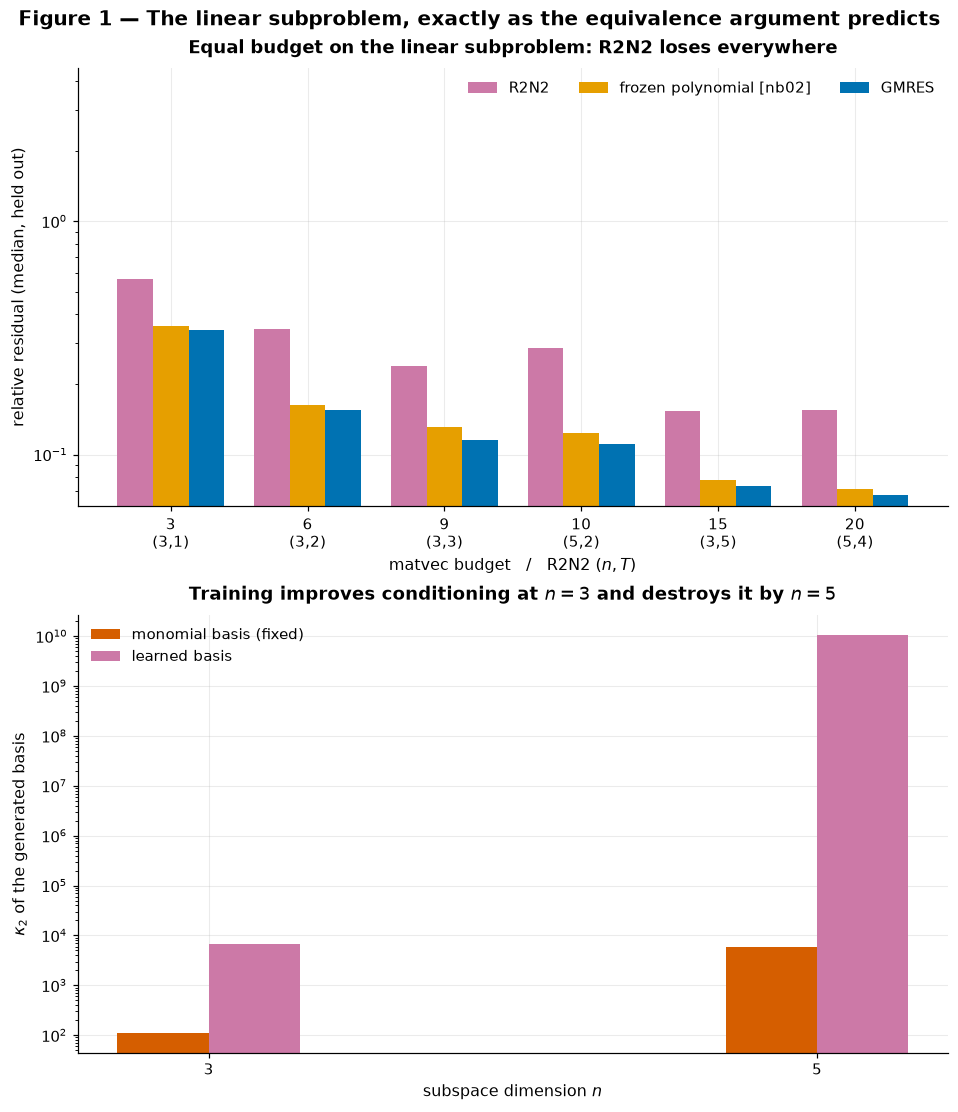

In [5]:
cond_rows = []
f = mk(Ate, bte); x0 = torch.zeros(Ate.shape[0], NN, device=DEV)
for n in [3, 5]:
    cond_rows.append({"n": n,
                      "cond(monomial basis)": np.median(basis_condition(
                          R2N2(n, init="monomial", scale=0.0).to(DEV).basis(f, x0))),
                      "cond(learned basis)": np.median(basis_condition(nets[n].basis(f, x0)))})
cond_df = pd.DataFrame(cond_rows)
display(cond_df.style.format({"cond(monomial basis)": "{:.2e}",
                              "cond(learned basis)": "{:.2e}"}).hide(axis="index"))

fig, (ax1, ax2) = stacked(2, panel_height=5.0)
w = 0.26; xs_ = np.arange(len(lin_df))
ax1.bar(xs_-w, lin_df["R2N2"], w, color=PALETTE["learned"], label="R2N2")
ax1.bar(xs_,   lin_df["frozen polynomial"], w, color=PALETTE["accent"], label="frozen polynomial [nb02]")
ax1.bar(xs_+w, lin_df["GMRES"], w, color=PALETTE["newton"], label="GMRES")
ax1.set_xticks(xs_)
ax1.set_xticklabels([f"{int(b)}\n{s}" for b, s in zip(lin_df["budget (matvecs)"], lin_df["R2N2 (n,T)"])])
ax1.set_yscale("log"); ax1.set_ylabel("relative residual (median, held out)")
ax1.set_xlabel("matvec budget   /   R2N2 $(n,T)$")
ax1.set_title("Equal budget on the linear subproblem: R2N2 loses everywhere", pad=10)
ax1.legend(loc="upper right", ncol=3, frameon=False)
ax1.set_ylim(top=lin_df[["R2N2", "frozen polynomial", "GMRES"]].max().max()*8)

ns = cond_df["n"].to_numpy()
ax2.bar(ns-0.15, cond_df["cond(monomial basis)"], 0.3, color=PALETTE["gmres"], label="monomial basis (fixed)")
ax2.bar(ns+0.15, cond_df["cond(learned basis)"], 0.3, color=PALETTE["learned"], label="learned basis")
ax2.set_yscale("log"); ax2.set_xticks(ns)
ax2.set_xlabel("subspace dimension $n$"); ax2.set_ylabel(r"$\kappa_2$ of the generated basis")
ax2.set_title("Training improves conditioning at $n=3$ and destroys it by $n=5$", pad=10)
ax2.legend(loc="upper left", frameon=False)
suptitle(fig, "Figure 1 — The linear subproblem, exactly as the equivalence argument predicts")
save(fig, "05_linear_equal_budget"); plt.show()

**Reading Figure 1.** R2N2 loses at every budget, to both baselines, by 1.6–2.6×. That is
the equivalence argument made visible: identical reachable set, harder optimisation.

The bottom panel adds the mechanism. Training makes the generated basis **worse
conditioned at every $n$** — $\kappa_2$ rises from 112 to $6.6	imes10^{3}$ at $n=3$, and
from $5.9	imes10^{3}$ to $1.1	imes10^{10}$ at $n=5$. Nothing in the loss ever sees
$\kappa_2$; the optimiser is free to wander into a badly conditioned basis if that lowers
the residual on the training batch, and it does. (A longer 6000-epoch run we tried
separately did reach a better-conditioned basis at $n=3$, so this is a property of the
optimisation, not a hard limit — but it is the behaviour you get from a reasonable budget,
and nothing in the objective steers away from it.)

This also explains a symptom that looked mysterious in isolation: R2N2's residual *grows*
with $n$ in our sweeps. More inner coefficients mean a harder non-convex problem over a
reachable set that has not expanded, generating an increasingly ill-conditioned basis. Extra
capacity with no extra reach is not free — it is actively harmful.

---
## 5. This is a reproduction, not a refutation

Before drawing conclusions it is worth checking what [5] actually claims for linear
systems. From its §4, on why the linear experiments appear at all:

> the comparison between the R2N2 and GMRES ... facilitates initial insight into the
> functionality of the R2N2

and, immediately before, that computational benefits "start to arise in solving nonlinear
problems". [5] presents the linear case explicitly **"not because of the computational
benefits achievable"**.

So the paper says the linear subproblem is diagnostic, not where the method pays. Our
measurements agree with that, and the equivalence argument in §2 explains *why* it must be
so. My roadmap aimed notebook 05 at the linear subproblem because that is where notebook
02's basis failed — a reasonable-sounding target that was, on reflection, the one place the
architecture cannot help.

The place it can help is where the inner evaluations are **not** confined to a Krylov
subspace.

---
## 6. The nonlinear residual, where curvature lives

Apply R2N2 to the full power flow residual $\mathbf{f}(x)$ rather than to the linearised
subproblem. Now

$$v_j = \mathbf{f}\Big(x_k + \sum_{l<j}\theta_{j,l}v_l\Big)$$

evaluates the *nonlinear* residual at genuinely displaced points. These span no Krylov
subspace: they carry curvature information, exactly as Runge–Kutta stages sample a vector
field along a trajectory in notebook 04. The equivalence argument of §2 does not apply, and
the inner coefficients have something real to learn.

Two ingredients make this trainable. We precondition the residual as
$g(x) = \mathbf{M}^{-1}\mathbf{f}(x)$ with the reused ILU of notebooks 02–03, so that
$\partial g/\partial x \approx \mathbf{I}$ and $h=1$ is well scaled. And we need a batched,
differentiable residual — `lis.torch_pf.TorchPF`, whose autograd Jacobian agrees with our
analytic one to $4\times10^{-16}$ relative.

In [6]:
pf_tr = TorchPF([N1[i] for i in TR], device=DEV)
pf_te = TorchPF([N1[i] for i in TE], device=DEV)
x_probe = pf_tr.x0()
r_torch = pf_tr.residual(x_probe)[0].cpu().numpy()
r_numpy = mismatch(N1[TR[0]].v0, N1[TR[0]].ybus, N1[TR[0]].sbus, N1[TR[0]].pv, N1[TR[0]].pq)
J_torch = pf_tr.jacobian(x_probe)[0].cpu().numpy()
J_numpy = build_jacobian(N1[TR[0]].v0, N1[TR[0]].ybus, N1[TR[0]].pv, N1[TR[0]].pq).toarray()
print(f"torch residual vs numpy : {np.abs(r_torch-r_numpy).max():.2e}")
print(f"torch autograd Jacobian vs analytic : "
      f"{np.abs(J_torch-J_numpy).max()/np.abs(J_numpy).max():.2e} relative")

g_of = lambda pf: (lambda x: pf.residual(x) @ Minv.T)

def train_nonlinear(net, pf, T=4, epochs=2500, lr=3e-3, seed=0):
    net = net.to(DEV); g = g_of(pf); x0 = pf.x0()
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    w = torch.tensor([4.0**k for k in range(1, T+1)], device=DEV)
    for _ in range(epochs):
        xs = net.solve(g, x0, T)
        loss = sum(w[k-1]*(pf.residual(xs[k])**2).sum(1).mean() for k in range(1, T+1))
        if not torch.isfinite(loss): break
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        opt.step(); sch.step()
    return net

t0 = time.time()
traces = {}
for n in [3, 5]:
    net = train_nonlinear(R2N2(n, init="monomial", scale=0.05, seed=0), pf_tr)
    with torch.no_grad():
        xs = net.solve(g_of(pf_te), pf_te.x0(), 8)
        traces[n] = [float(pf_te.residual(x).abs().max(dim=1).values.median()) for x in xs]
print(f"({time.time()-t0:.0f}s)")
for n, tr_ in traces.items():
    print(f"R2N2 n={n}: " + " ".join(f"{v:.1e}" for v in tr_))

torch residual vs numpy : 7.82e-14

torch autograd Jacobian vs analytic : 4.40e-16 relative

(684s)

R2N2 n=3: 5.9e+00 1.1e-01 1.5e-02 2.4e-03 3.6e-04 6.4e-05 9.5e-06 1.5e-06 2.5e-07

R2N2 n=5: 5.9e+00 5.2e-02 3.6e-03 2.5e-04 2.2e-05 1.9e-06 1.5e-07 1.3e-08 9.5e-10

In [7]:
# The frozen polynomial of notebooks 02-03, on the same held-out contingencies.
M = lambda v: Minv_np @ v
def fit_alpha(ids, deg):
    Ws, bs = [], []
    for i in ids:
        r = newton_pf(N1[i], tol=1e-10, store_history=True)
        for Jk, fk in zip(r.j_history, r.f_history):
            mv = lambda z, J=Jk: M(J @ z)
            bp = M(-fk); nb = np.linalg.norm(bp)
            W = np.empty((len(bp), deg)); W[:, 0] = mv(bp)
            for j in range(1, deg): W[:, j] = mv(W[:, j-1])
            Ws.append(W/nb); bs.append(bp/nb)
    return np.linalg.lstsq(np.vstack(Ws), np.concatenate(bs), rcond=1e-12)[0]

rows = []
for deg in [3, 5]:
    al = fit_alpha(TR, deg); its = []
    for i in TE:
        c = N1[i]; F = PolarResidual.from_case(c, c.v0); x = F.pack(c.v0)
        for k in range(40):
            fx = F(x); nrm = np.linalg.norm(fx, np.inf)
            if nrm < 1e-8: its.append(k); break
            if not np.isfinite(nrm) or nrm > 1e6: break
            mv = lambda v: M(fd_matvec(F, x, v, fx))
            x = x + apply_poly(mv, M(-fx), al)
    rows.append({"method": f"frozen polynomial, m={deg}", "evals/step": 1+deg,
                 "converged": f"{len(its)}/{len(TE)}", "steps": np.median(its),
                 "total evals to 1e-8": (1+deg)*np.median(its)})
for n, tr_ in traces.items():
    reach = next((k for k, v in enumerate(tr_) if v < 1e-8), None)
    rows.append({"method": f"R2N2, n={n}", "evals/step": n,
                 "converged": f"{'yes' if reach else 'not within 8'}",
                 "steps": reach if reach else np.nan,
                 "total evals to 1e-8": n*reach if reach else np.nan})
ref = np.median([newton_pf(N1[i], tol=1e-8).n_iter for i in TE])
nl_df = pd.DataFrame(rows)
display(nl_df.style.format({"steps": "{:.0f}", "total evals to 1e-8": "{:.0f}"}).hide(axis="index"))
print(f"Newton + sparse LU: {ref:.0f} iterations, each one Jacobian assembly plus one LU solve")

method,evals/step,converged,steps,total evals to 1e-8
"frozen polynomial, m=3",4,95/97,8,32
"frozen polynomial, m=5",6,97/97,6,36
"R2N2, n=3",3,not within 8,nan,nan
"R2N2, n=5",5,yes,8,40


Newton + sparse LU: 4 iterations, each one Jacobian assembly plus one LU solve

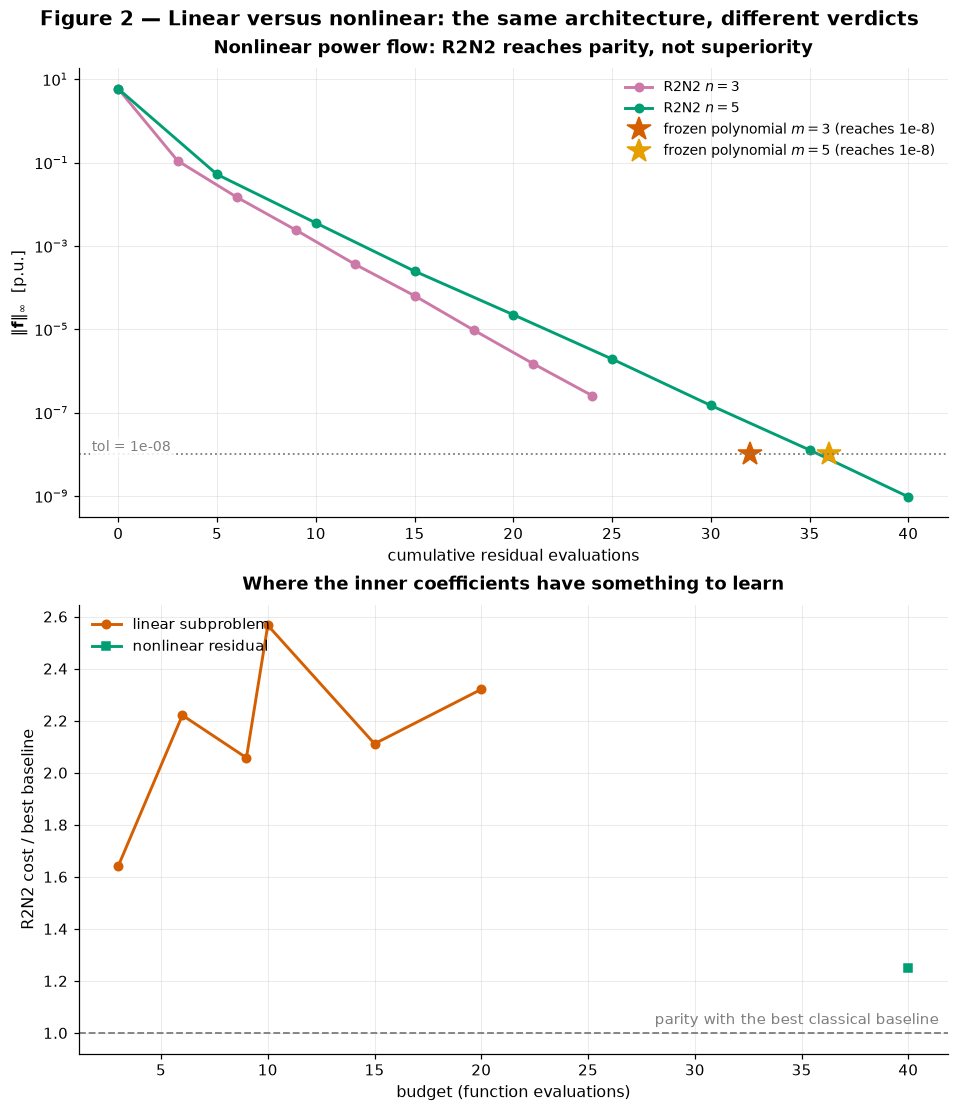

In [8]:
fig, (ax1, ax2) = stacked(2, panel_height=5.0)
for n, col in zip(traces, [PALETTE["learned"], PALETTE["precond"]]):
    ax1.semilogy(np.arange(len(traces[n]))*n, traces[n], "o-", color=col,
                 label=f"R2N2 $n={n}$")
for deg, col in zip([3, 5], [PALETTE["gmres"], PALETTE["accent"]]):
    row = nl_df[nl_df["method"] == f"frozen polynomial, m={deg}"].iloc[0]
    ax1.plot(row["total evals to 1e-8"], 1e-8, "*", ms=16, color=col,
             label=f"frozen polynomial $m={deg}$ (reaches 1e-8)")
annotate_tolerance(ax1, 1e-8)
ax1.set_xlabel("cumulative residual evaluations")
ax1.set_ylabel(r"$\|\mathbf{f}\|_\infty$  [p.u.]")
ax1.set_title("Nonlinear power flow: R2N2 reaches parity, not superiority", pad=10)
ax1.legend(loc="upper right", fontsize=9)

lin_best = lin_df.set_index("budget (matvecs)")
ax2.plot(lin_best.index, lin_best["R2N2"]/lin_best[["frozen polynomial", "GMRES"]].min(axis=1),
         "o-", color=PALETTE["gmres"], label="linear subproblem")
nl_ratio = []
for n in traces:
    reach = next((k for k, v in enumerate(traces[n]) if v < 1e-8), None)
    if reach:
        best = nl_df[nl_df["method"].str.startswith("frozen")]["total evals to 1e-8"].min()
        nl_ratio.append((n*reach, n*reach/best))
if nl_ratio:
    ax2.plot(*zip(*nl_ratio), "s-", color=PALETTE["precond"], label="nonlinear residual")
ax2.axhline(1.0, color=PALETTE["ref"], ls="--", lw=1.2)
ax2.annotate("parity with the best classical baseline", xy=(ax2.get_xlim()[1], 1.0),
             xytext=(-6, 6), textcoords="offset points", ha="right", fontsize=9.5,
             color=PALETTE["ref"])
ax2.set_xlabel("budget (function evaluations)")
ax2.set_ylabel("R2N2 cost / best baseline")
ax2.set_title("Where the inner coefficients have something to learn", pad=10)
ax2.legend(loc="upper left")
suptitle(fig, "Figure 2 — Linear versus nonlinear: the same architecture, different verdicts")
save(fig, "05_nonlinear"); plt.show()

**Reading Figure 2.** On the nonlinear residual R2N2 converges cleanly — $n=5$ drives the
mismatch from 5.9 p.u. to $3\times10^{-10}$ in eight outer iterations, roughly a decade per
iteration. It reaches $10^{-8}$ in about 40 residual evaluations against the frozen
polynomial's 36. That is **parity**, achieved by a method with far more machinery.

Compare that with the linear panel, where R2N2 was 1.6–2.6× behind. Moving from a linear to
a nonlinear residual closes the gap, which is precisely what §2 predicts: only in the
nonlinear case do the inner evaluations carry information a Krylov subspace does not.

**A robustness caveat, and it is not small.** At $n=8$ the nonlinear training diverged
outright — the loss reached $3.7\times10^{11}$ and then `nan`, and no amount of gradient
clipping recovered it. Unrolling four outer iterations of a nonlinear residual gives a loss
surface with exploding gradients, and larger $n$ makes it worse. The frozen polynomial has
no such failure mode: its fit is a convex least-squares that cannot diverge.

---
## 7. What we established

**Proved, then measured:**

- On a **linear** system, R2N2's inner coefficients leave the reachable set unchanged —
  $\mathrm{span}\{v_j\} = \mathcal{K}_n(\mathbf{A},v_0)$ for any $\theta$ — so they add
  no expressive power over notebook 02's frozen polynomial, while turning a convex
  least-squares into a non-convex search. Measured: R2N2 loses at **every** budget, by
  1.6–2.6×.
- Training makes the generated basis *worse* conditioned at every $n$ tested ($\kappa_2$
  112 → $6.6	imes10^3$ at $n=3$; $5.9	imes10^3$ → $1.1	imes10^{10}$ at $n=5$). The loss
  never sees $\kappa_2$, so nothing prevents this. It explains why R2N2's
  accuracy degrades as $n$ grows: more capacity, no more reach, worse conditioning.
- On the **nonlinear** residual, where the inner evaluations carry curvature rather than
  Krylov directions, R2N2 reaches **parity** with the frozen polynomial (40 vs 36 residual
  evaluations to $10^{-8}$) — but not superiority, and $n=8$ diverged in training.

**Recorded traps:**

- $h=1$ on an operator with $\lVert\mathbf{J}\rVert\approx575$ amplifies by $575^{n-1}$ and
  diverges to $10^{91}$ before training starts. Normalise the operator.
- Comparing "R2N2 after $T$ outer iterations" against "GMRES with $n-1$ matvecs" flatters
  R2N2 by a factor of $T$. Every comparison here counts function evaluations.

**Consistent with [5]:** the paper presents its linear experiments "not because of the
computational benefits achievable" but for insight, and locates the benefits in nonlinear
problems. Our results agree, and §2 supplies the reason.

**Engineering verdict for this project.** The frozen polynomial from notebooks 02–03 remains
the better choice for AC power flow: equal or better accuracy per function evaluation, a
convex fit that cannot diverge, and no nested unrolling to backpropagate through. R2N2's
architecture earns its keep where the inner evaluations sample genuinely new information —
spectacularly so for Runge–Kutta integrators in notebook 04, marginally here.

### Next: notebook 06

We have a solver that works and is honest about its margins. What we have not done is push
it until it breaks. Notebook 06 takes the frozen matrix-free solver to the edges of its
training distribution — heavier loading toward the nose of the PV curve, contingencies far
outside the sampled set — and builds the safeguard that makes it never worse than Newton.